# Machine Learning

## Anomaly Detection 💥

___

# I. Introduction to anomaly detection

## I.1. Anomaly detection applications

Many problems in real life aim to detect anomalies, for example:

- in the industry, given test results (vibration tests, heat tests, etc.) of newly created planes, does the aircraft present any anomaly?

<img src="images/airbbus.jpg" width="600px" />

- in the financial sector, among all the transactions we process is there any fraud transactions ongoing?

<img src="images/creditcard.jpg" width="600px" />

- according to the server logs we collect, can we detect any malfunction, overloading, unusual server or activity etc.? Features would for example CPU load, memory use, network traffic, etc.

<img src="images/serveroverload.jpg" width="600px" />

- in manufacturing industry, can we automate visual quality inspection by detecting anomalies on the faulty pieces

<img src="images/visual-inspection.png" width="600px" />

- in cybersecurity, based on user activity on a website (# pages visited, typing speed, ) flag unusual users

<img src="images/unusual-activity-google.png" width="600px" />

## I.2. Unsupervised due to imbalanced data

Supervised  approaches (classifying anomaly vs normal behavior) can be challenging in anomaly detection problems as the data is most ofen **largely imbalanced**

> 🔦 **Hint**: As the anomalies are supposedly rare events, it's often difficult to obtain large amounts of labeled anomalies. So the labeled data consists mostly of normal events.

Therefore, we need to come up with new approaches to tackle this problem:
- moving back to a **supervised problem** using **undersampling** or **oversampling** can be an option
- most anomaly detection approachs consist in treating this as an **unsupervised problem** and trying to identify anomalies as **outliers** compared to the normal data points. 

<img src="images/outliers.png" width="400px"/>

---

# II. Anomaly detection algorithms

There exist multiple algorithms that aim to detect anomalies. We will unveil some of the most popular.

Similarly to supervised methods, results vary depending on the model you choose and it's part of your job to test different algorithms, to iterate, and to have a good sense your data distribution in order to make the right choice.

<img src="images/comparison-models.png" width="600px"/>

## II.1. Gaussian distribution based

### II.1.A. Intuition 

Imagine you collect two test measures (heating and pressure resistance) of an aircraft piece after fabrication.

Let's visualize the distribution of the normal pieces we tested:

<img src="images/data-distribution.png" width="300px" />

We would presume, that if a new aircraft piece is being made with test measures far from those previously collected, the chance are high that this new piece is an anomaly.

Using probability laws to modelize our data, we can compute the probability of any new given point and conclude on whether we consider it as an anomaly or not.

### II.1.B. Gaussian distribution

This is how the Gaussian distribution based algorithm works: based on the existing data distribution, we modelize each selected feature $x_i$ by a Normal law (bell curve)

$$P(x_i,\mu_i,\sigma_i) =  {e} ^{-{\frac {1}{2}}\left({\frac {x_i-\mu_i }{\sigma_i }}\right)^{2}} $$

> 🔦 **Hint**: For each feature $i$, the model learns two parameters: ${\mu_i }$ the mean and ${\sigma_i}$ the standard deviation of the normal law.

So that the probability of a point $x$ is given by the multiplication of those distributions:

$$P(x) = \prod_i P(x_i,\mu_i,\sigma_i) $$

Finally, for a new datapoint $x_{test}$, we can assume the point as being normal if the probability is "high enough" or flag it as an anomaly if the probability is "too small".

To do so, we fix an hyperparameter $\epsilon$ (for example 0.2), that corresponds to the **anomaly threshold**:

* if $P(x_{test}) < \epsilon$: then this point is classified as an anomaly
* if $P(x_{test}) \geq \epsilon$: then this point is classified normal

The value of $\epsilon$ has to be defined properly on the validation dataset to maximize the chosen evaluation metrics.

## II.2. Local Outlier Factor (LOF)

Another efficient way to perform outlier detection consists of using the **Local Outlier Factor (LOF)** algorithm.

The LOF algorithm computes a score (called Local Outlier Factor) reflecting the **degree of abnormality of the observations**.

This score can be interpreted as such: a normal instance is expected to have a local density similar to that of its neighbors, while abnormal data are expected to have much smaller local density.
* if LOF $\lesssim$	1 this point is **normal**
* if LOF >> 1 this point is **anomalous**

<img src="images/lof.png" width="400px" />

> 🔦 **Hint**: The strength of the LOF algorithm is that **it takes both local and global properties** of datasets **into consideration**. The question is not, how isolated the sample is, but how isolated it is with respect to the surrounding neighborhood.

> 🔦 **Hint**: In practice, taking `n_neighbors=20` appears to work well in general. When the proportion of outliers is high (i.e. greater than 10%), `n_neighbors` should be greater.

> 📚 **Resources**: if you want to dig into the details of the LOF score, have a look at [scikit-learn clear explanation](https://scikit-learn.org/stable/modules/outlier_detection.html#local-outlier-factor).

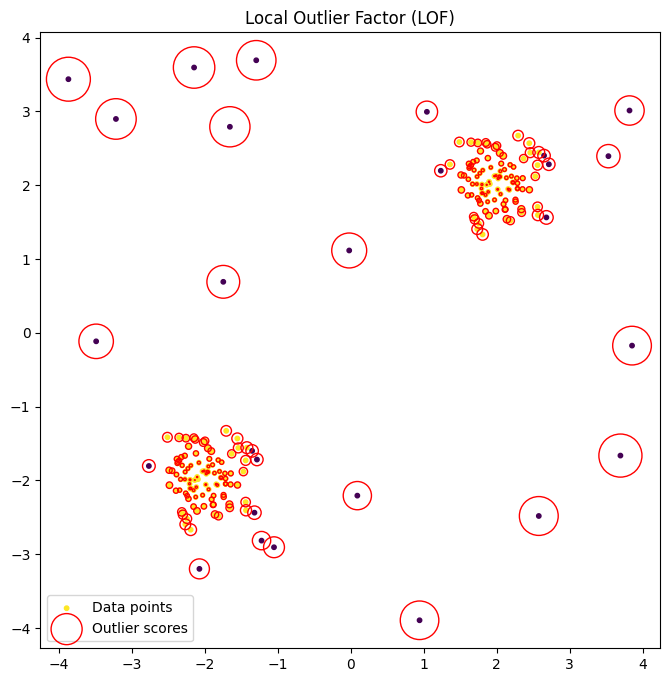

prediction errors: 9
Negative LOF scores: [-1.21526994 -1.37913794 -1.30255202 -0.99933436 -0.95206526 -1.12729583
 -0.98273885 -0.98791362 -1.09360181 -1.03046301 -1.53240984 -1.04756354
 -1.66610309 -0.95598229 -1.32617544 -0.97109464 -1.40173602 -0.9521733
 -1.2062911  -0.96422171 -1.22187372 -1.30438896 -0.97203331 -1.01956882
 -1.10229141 -0.98318878 -1.06206075 -0.95871984 -0.95985286 -0.9650733
 -0.96792884 -1.28840385 -0.97317116 -1.09161947 -0.97000714 -0.98075357
 -1.17777365 -1.02023152 -1.01765914 -0.9462536  -1.03057369 -1.15760264
 -1.41838856 -1.03656554 -1.03536656 -1.05411277 -1.03087907 -0.99747171
 -1.17056327 -0.97048721 -1.4320476  -1.04598131 -1.19844733 -0.98745639
 -1.4880337  -1.3274062  -1.1625892  -0.98168647 -0.99868045 -1.00655058
 -1.0643051  -1.11729121 -0.96486938 -1.1555278  -0.99151673 -0.98470058
 -0.96089524 -0.97931425 -0.96582556 -1.05538496 -1.04446673 -0.97228819
 -1.53584793 -1.03336574 -1.04349399 -1.17490717 -1.05448604 -0.9923758
 -1.13280472

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(0)

# Generate train data
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Generate some outliers
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_inliers, X_outliers]

n_outliers = len(X_outliers)
y = np.ones(len(X), dtype=int)
y[-n_outliers:] = -1

# fit the model for outlier detection (default)
clf = LocalOutlierFactor(n_neighbors=20, contamination="auto")
# use fit_predict to compute the predicted labels of the training samples
# (when LOF is used for outlier detection, the estimator has no predict,
# decision_function and score_samples methods).
y_pred = clf.fit_predict(X)
n_errors = (y_pred != y).sum()
X_scores = clf.negative_outlier_factor_

plt.figure(figsize=(8,8))

plt.title("Local Outlier Factor (LOF)")
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=10., label='Data points')

# plot circles with radius proportional to the outlier scores
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
plt.scatter(X[:, 0], X[:, 1], s=1000 * radius, edgecolors='r',
            facecolors='none', label='Outlier scores')
legend = plt.legend(loc='lower left')
plt.show()
print("prediction errors: {}".format(n_errors))
print("Negative LOF scores: {}".format(clf.negative_outlier_factor_))
print("Offset (threshold to consider sample as anomaly or not): {}".format(clf.offset_))

## II.3. Isolation Forest

### II.3.A. Intuition

As you could guess, **Isolation Forest** is an algorithm based on Random Forests algorithm. 

Indeed, knowing that outliers (anomalous points) are usually farther in the distribution of points, decision trees would **need less steps to isolate such a point than a regular point**.

This is well represented in the examples belowe (where $x_i$ is a regular point and $x_0$ an anomaly):

<img src="images/isolation_forest.png" width="800px" />
          
<table><tr><td><img src='images/inlier2.gif' width="400px"></td><td><img src='images/outlier2.gif' width="400px"></td></tr></table>

### II.3.B. Details

In other words, the IsolationForest ‘isolates’ observations by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature.

Since recursive partitioning can be represented by a tree structure, the number of splittings required to isolate a sample is equivalent to the path length from the root node to the terminating node.

This path length, averaged over a forest of such random trees, is a measure of normality and our decision function.

Then one can compute the path to isolate each point, and compare it to the average path, using the formula:

$${ \displaystyle s(x,n) = \displaystyle2^{ \frac{-mean(h(x))}{c(n)}}}  $$

where:
* $h(x)$ is the path length from root node to node $x$
* $mean(h(x))$ is the average path length over several decision trees
* $c(n)$ is the average path length for all nodes, it's just a normalisation factor

Finally, depending on the value of $s(x)$, three possibilities:
* if $s(x) \approx 1$ , ie $mean(h(x)) \ll c$, x is an anomaly
* if $s(x) \ll 0.5 $, ie $mean(h(x)) \gg c$, x is normal
* if $s(x) \approx 0.5$ for all points, there is no distinct anomaly in the data

> 📚 **Resources**: [Read more](https://quantdare.com/isolation-forest-algorithm/) about isolation forests

### II.3.C. Implementation

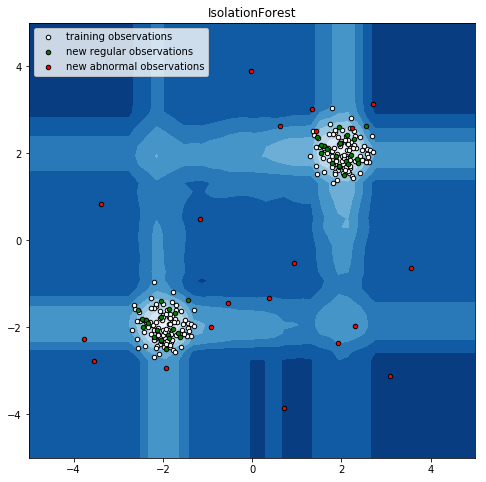

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Generate train data
X = 0.3 * np.random.randn(100, 2)
X_train = np.r_[X + 2, X - 2]
# Generate some regular novel observations
X = 0.3 * np.random.randn(20, 2)
X_test = np.r_[X + 2, X - 2]
# Generate some abnormal novel observations
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

# fit the model
clf = IsolationForest(max_samples=100, contamination='auto', behaviour='new')
clf.fit(X_train)

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)
y_pred_outliers = clf.predict(X_outliers)

# plot the line, the samples, and the nearest vectors to the plane
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 8))
plt.title("IsolationForest")
plt.contourf(xx, yy, Z, cmap=plt.cm.Blues_r)

b1 = plt.scatter(X_train[:, 0], X_train[:, 1], c='white',
                 s=20, edgecolor='k')
b2 = plt.scatter(X_test[:, 0], X_test[:, 1], c='green',
                 s=20, edgecolor='k')
c = plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red',
                s=20, edgecolor='k')

plt.legend([b1, b2, c],
           ["training observations",
            "new regular observations", "new abnormal observations"],
           loc="upper left")
plt.show()


## II.4. Auto-Encoder

An other powerful outlier detection model is called **Auto-Encoder**.

It is a **Deep Learning unsupervised technique** that aims to encode data into a smaller set of features and decode it afterward. When an anomaly is encountered, the Auto-Encoder does not manage to decode properly, thus meaning the sample is an anomaly.

Below is the architectural structure of an encoder:

<img src="images/Autoencoder_structure.png" width="600px" />

---

# III. Algorithms comparison

Let's finally apply what we just learnt on an example:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

First we generate some training data of normal points. We create two clusters generated randomly through a normal distribution. This makes a training set of 2000 data points

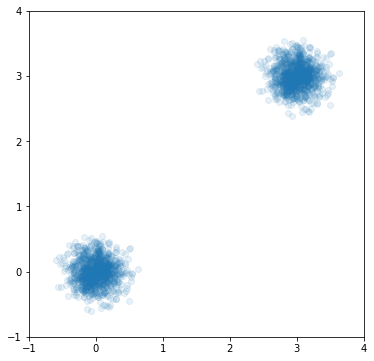

In [132]:
N_POINTS_TRAIN = 1000
DIMENSION = 2

np.random.seed(0)

# 2D gaussian distribution, 0.2 is just a normalization factor
# Actually, we make 2 gaussian distribution, then merge them into a single array
gaussian_train = 0.2 * np.random.randn(N_POINTS_TRAIN, DIMENSION)
X_train = np.concatenate([gaussian_train, gaussian_train + 3])
X_train = pd.DataFrame(X_train, columns = ['x1', 'x2'])

plt.figure(figsize=(6, 6))
plt.scatter(X_train['x1'], X_train['x2'], label='Train', alpha=0.1)
plt.xlim([-1, 4])
plt.ylim([-1, 4])
plt.show()

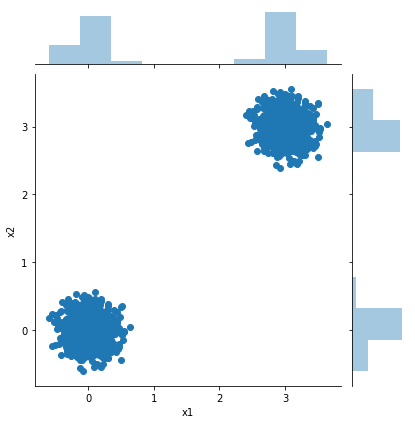

In [156]:
sns.jointplot(X_train["x1"], X_train["x2"],kind="scatter")
plt.show()

Then we generate some testing data composed of normal point and outliers. Inliers are created the same way (using normal distribution) and outliers are created everywhere (using uniform distribution).

This makes a testing set of 440 testing points (400 normal and 40 outliers).

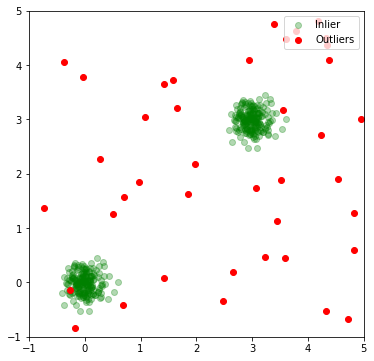

In [169]:
# Generating new, 'normal' observation for test
N_POINTS_TEST = 200
gaussian_test = 0.2 * np.random.randn(N_POINTS_TEST, DIMENSION)
X_test = np.concatenate([gaussian_test + 3, gaussian_test]) #number of test points is 400
X_test = pd.DataFrame(X_test, columns = ['x1', 'x2'])

# Generating outliers for test
N_OUTLIERS = 40
X_outliers = np.random.uniform(low=-1, high=5, size=(N_OUTLIERS, DIMENSION))
X_outliers = pd.DataFrame(X_outliers, columns = ['x1', 'x2'])

# Concatenate normal and outliers distributions for test
X_test_good = pd.concat([X_test, X_outliers])
y = np.zeros(440) #flag normal values as 0
y[400:] = 1 #flag outliers as 1

# Plotting data
plt.figure(figsize=(6, 6))
plt.scatter(X_test['x1'], X_test['x2'], color="g", label='Inlier', alpha=0.3)
plt.scatter(X_outliers['x1'], X_outliers['x2'], color="r", label='Outliers')
plt.legend(loc=1)
plt.xlim([-1,5])
plt.ylim([-1,5])
plt.show()

Based on those newly created data, we can apply the algorithms we explained.

In [177]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, precision_score, accuracy_score, recall_score, f1_score

# Instantiate the models
IF = IsolationForest(contamination="auto", behaviour="new") #contamination: amount of outliers to determine threshold value for outlier detection ; behaviour new is to match scikit-learn decision_function method in other anomaly detection algorithms 
LOF = LocalOutlierFactor(contamination="auto", novelty=True) #novelty: allows to find new kind of outliers

# Fit the data
IF.fit(X_train)
LOF.fit(X_train)

# Perform the prediction
ypredIF = IF.predict(X_test_good)
ypredLOF = LOF.predict(X_test_good)

# Warning, those algorithm return -1 for anomaly and 1 for normal!!
ypredIF[ypredIF == 1] = 0
ypredIF[ypredIF == -1] = 1
ypredLOF[ypredLOF == 1] = 0
ypredLOF[ypredLOF == -1] = 1

# Print the results
print("##################\nIsolation Forest results:")
print(classification_report(y, ypredIF))

print("##################\nLOF results:")
print(classification_report(y, ypredLOF))

##################
Isolation Forest results:
              precision    recall  f1-score   support

         0.0       1.00      0.80      0.89       400
         1.0       0.33      0.97      0.49        40

   micro avg       0.82      0.82      0.82       440
   macro avg       0.66      0.89      0.69       440
weighted avg       0.94      0.82      0.85       440

##################
LOF results:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99       400
         1.0       0.83      0.97      0.90        40

   micro avg       0.98      0.98      0.98       440
   macro avg       0.91      0.98      0.94       440
weighted avg       0.98      0.98      0.98       440



Your turn now! Leverage those new models in order to improve your results on credit card fraud detection! 🚀